In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv("project1_df.csv")
df.head()

,CID,TID,Gender,Age Group,Purchase Date,Product Category,Discount Availed,Discount Name,Discount Amount (INR),Gross Amount,Net Amount,Purchase Method,Location
0,943146,5876328741,Female,25-45,30/08/2023 20:27:08,Electronics,Yes,FESTIVE50,64.30,725.304000,661.004000,Credit Card,Ahmedabad
1,180079,1018503182,Male,25-45,23/02/2024 09:33:46,Electronics,Yes,SEASONALOFFER21,175.19,4638.991875,4463.801875,Credit Card,Bangalore
2,337580,3814082218,Other,60 and above,06/03/2022 09:09:50,Clothing,Yes,SEASONALOFFER21,211.54,1986.372575,1774.832575,Credit Card,Delhi
3,180333,1395204173,Other,60 and above,04/11/2020 04:41:57,Sports & Fitness,No,NaN,0.00,5695.612650,5695.612650,Debit Card,Delhi
4,447553,8009390577,Male,18-25,31/05/2022 17:00:32,Sports & Fitness,Yes,WELCOME5,439.92,2292.651500,1852.731500,Credit Card,Delhi


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CID                    55000 non-null  int64  
 1   TID                    55000 non-null  int64  
 2   Gender                 55000 non-null  object 
 3   Age Group              55000 non-null  object 
 4   Purchase Date          55000 non-null  object 
 5   Product Category       55000 non-null  object 
 6   Discount Availed       55000 non-null  object 
 7   Discount Name          27415 non-null  object 
 8   Discount Amount (INR)  55000 non-null  float64
 9   Gross Amount           55000 non-null  float64
 10  Net Amount             55000 non-null  float64
 11  Purchase Method        55000 non-null  object 
 12  Location               55000 non-null  object 
dtypes: float64(3), int64(2), object(8)
memory usage: 5.5+ MB


In [46]:
df['Discount Name'] = df['Discount Name'].fillna('NO_DISCOUNT')
# If amount is 0 → no discount
df.loc[df['Discount Amount (INR)'] == 0, 'Discount Name'] = 'NO_DISCOUNT'

# If name is NO_DISCOUNT → amount = 0
df.loc[df['Discount Name'] == 'NO_DISCOUNT', 'Discount Amount (INR)'] = 0

In [47]:
df['Discount Name'].value_counts()

Discount Name
NO_DISCOUNT        27585
NEWYEARS            8135
SEASONALOFFER21     6940
FESTIVE50           4115
SAVE10              4115
WELCOME5            4110
Name: count, dtype: int64

In [48]:
df['Discount Name'] = df['Discount Name'].str.strip().str.upper()

In [49]:
print(df[df['Discount Name'] == 'NO_DISCOUNT'].head())


       CID         TID  Gender     Age Group        Purchase Date  \
3   180333  1395204173   Other  60 and above  04/11/2020 04:41:57   
6   668787  9460023916    Male         25-45  08/10/2023 16:59:52   
7   933551  6877673032  Female         18-25  14/12/2022 20:13:45   
8   414167  2841266620    Male         18-25  29/04/2020 09:10:46   
10  931578  5168806107   Other         25-45  09/12/2022 19:54:47   

    Product Category Discount Availed Discount Name  Discount Amount (INR)  \
3   Sports & Fitness               No   NO_DISCOUNT                    0.0   
6        Electronics               No   NO_DISCOUNT                    0.0   
7        Electronics               No   NO_DISCOUNT                    0.0   
8           Pet Care               No   NO_DISCOUNT                    0.0   
10          Clothing               No   NO_DISCOUNT                    0.0   

    Gross Amount  Net Amount Purchase Method Location  
3     5695.61265  5695.61265      Debit Card    Delhi  
6   

In [50]:
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])
df['Year'] = df['Purchase Date'].dt.year
df['Month'] = df['Purchase Date'].dt.month
df['Day'] = df['Purchase Date'].dt.day

/var/folders/rn/rzkx3h8j577b27w7ln9mjg4c0000gn/T/ipykernel_41374/4094543126.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])


In [51]:
cols = ['Purchase Date', 'CID', 'TID']
df = df.drop(columns=cols)

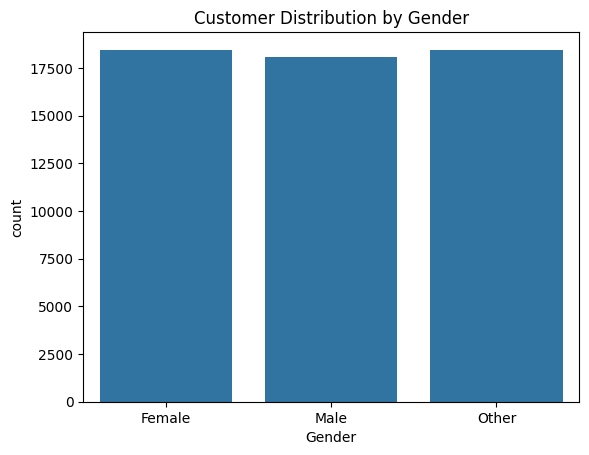

In [52]:
sns.countplot(x='Gender', data=df)
plt.title("Customer Distribution by Gender")
plt.show()

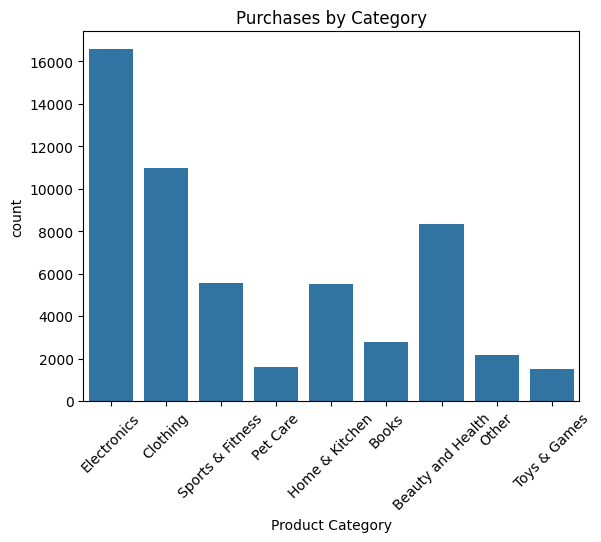

In [53]:
sns.countplot(x='Product Category', data=df)
plt.xticks(rotation=45)
plt.title("Purchases by Category")
plt.show()

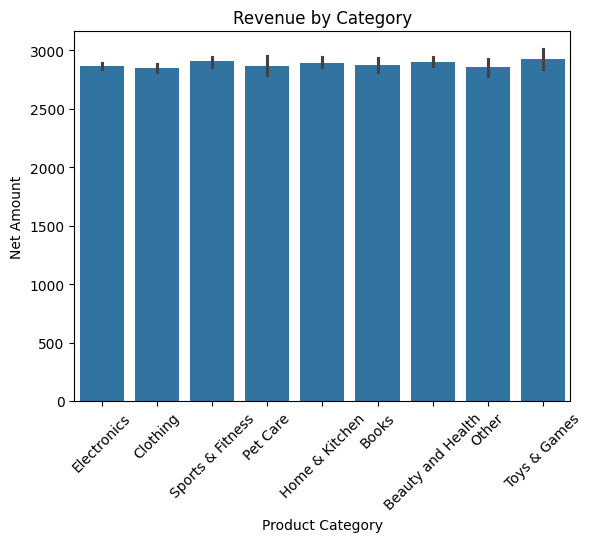

In [54]:
sns.barplot(x='Product Category', y='Net Amount', data=df)
plt.xticks(rotation=45)
plt.title("Revenue by Category")
plt.show()

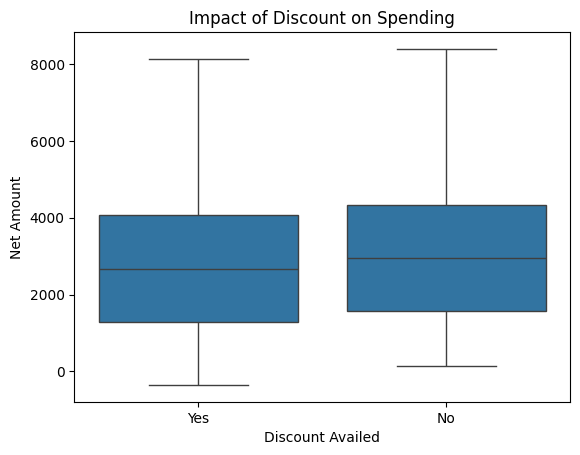

In [55]:
sns.boxplot(x='Discount Availed', y='Net Amount', data=df)
plt.title("Impact of Discount on Spending")
plt.show()

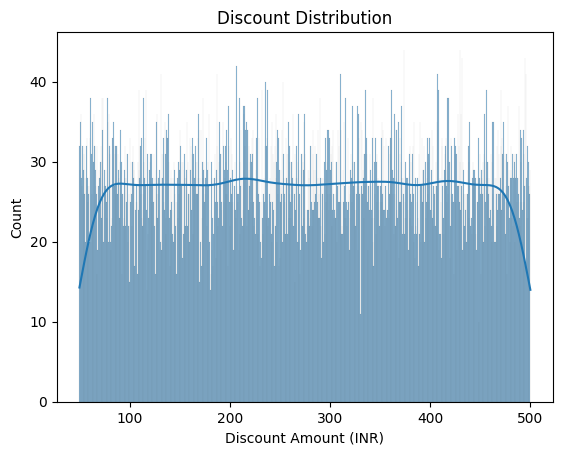

In [56]:
sns.histplot(df[df['Discount Amount (INR)']!=0]['Discount Amount (INR)'], bins=1000,kde=True)
plt.title("Discount Distribution")
plt.show()

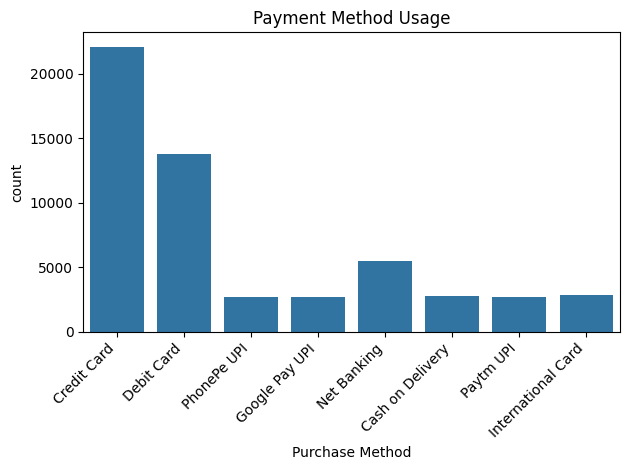

In [57]:
sns.countplot(x='Purchase Method', data=df)
plt.title("Payment Method Usage")
plt.xticks(rotation=45, ha='right')  # rotate labels
plt.tight_layout() 
plt.show()

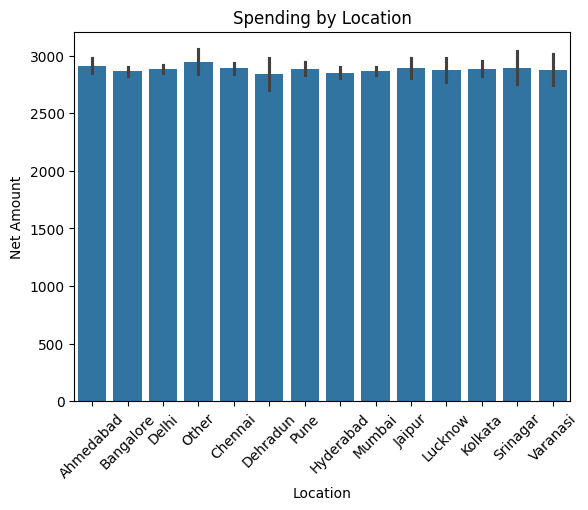

In [58]:
sns.barplot(x='Location', y='Net Amount', data=df)
plt.xticks(rotation=45)
plt.title("Spending by Location")
plt.show()

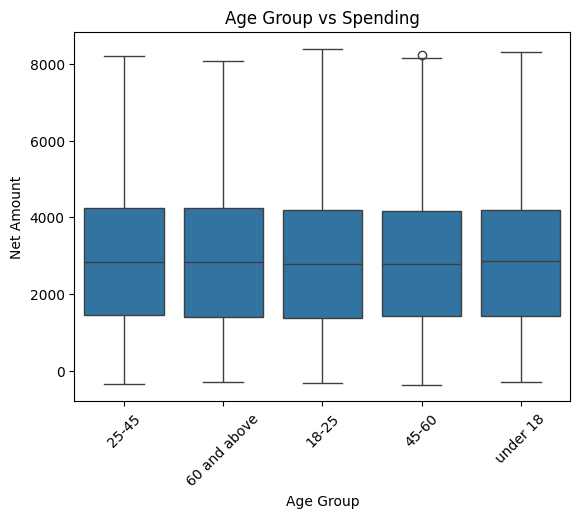

In [59]:
sns.boxplot(x='Age Group', y='Net Amount', data=df)
plt.xticks(rotation=45)
plt.title("Age Group vs Spending")
plt.show()

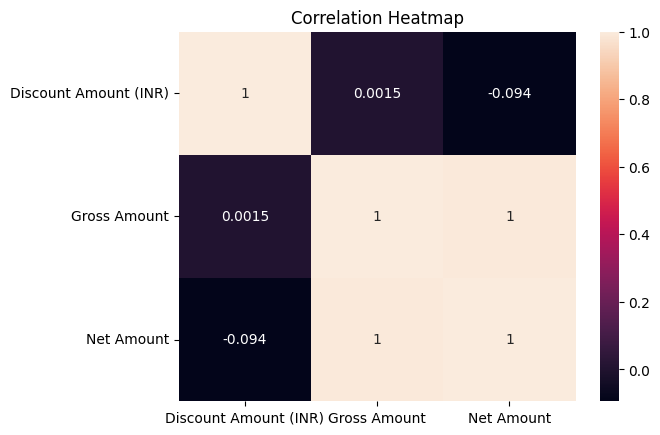

In [60]:
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

sns.heatmap(numeric_cols.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

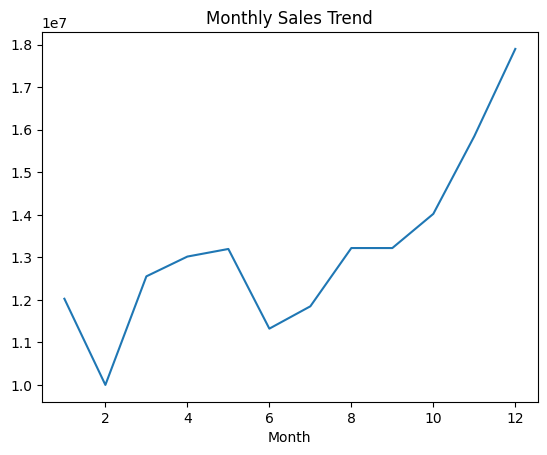

In [61]:
monthly_sales = df.groupby('Month')['Net Amount'].sum()

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.show()

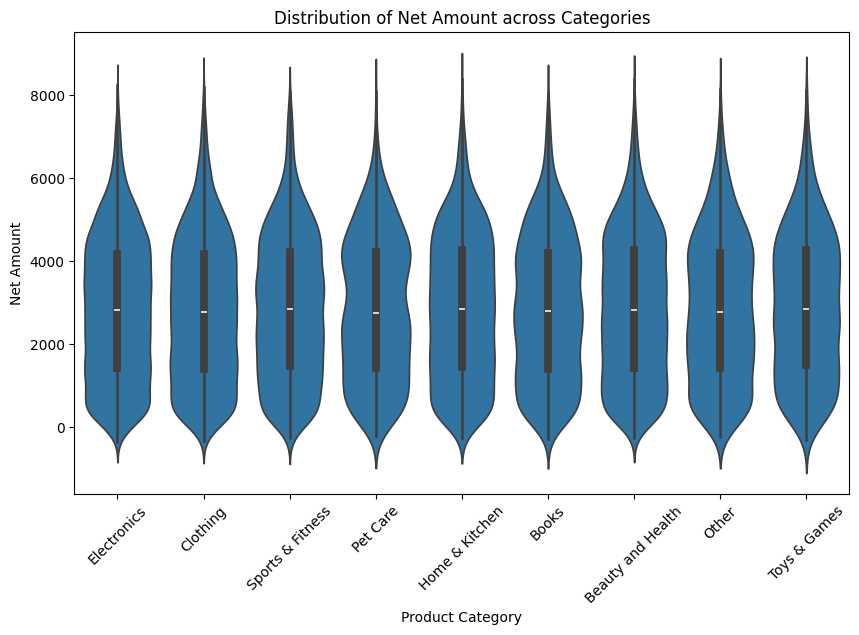

In [62]:
plt.figure(figsize=(10,6))
sns.violinplot(x='Product Category', y='Net Amount', data=df)
plt.xticks(rotation=45)
plt.title("Distribution of Net Amount across Categories")
plt.show()

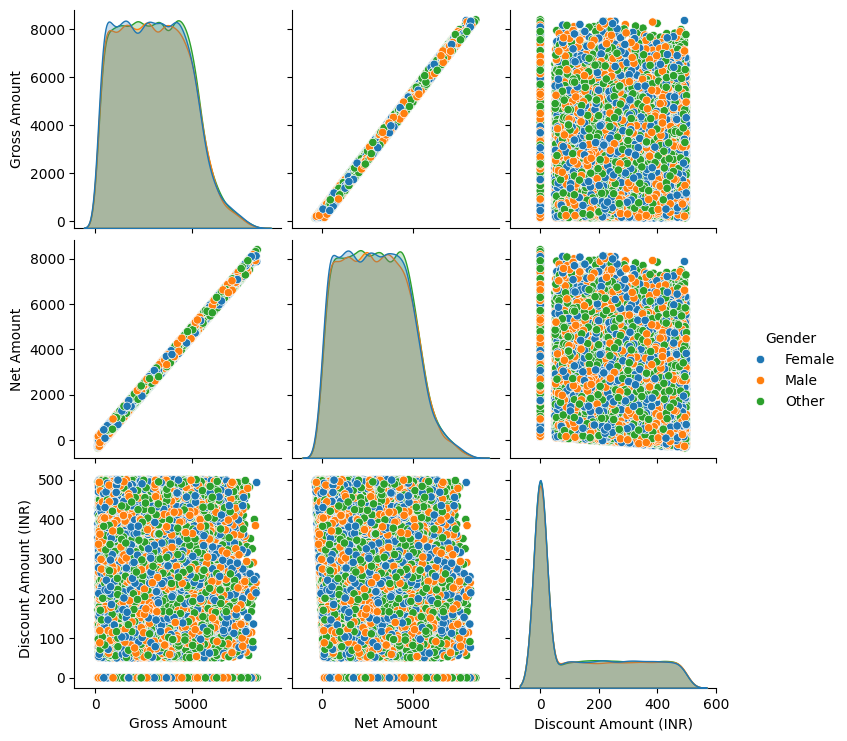

In [64]:
sns.pairplot(df, 
             vars=['Gross Amount', 'Net Amount', 'Discount Amount (INR)'],
             hue='Gender')
plt.show()

In [65]:
sns.set_style("whitegrid")   # options: white, dark, ticks
sns.set_palette("coolwarm")  # try: deep, muted, pastel, dark

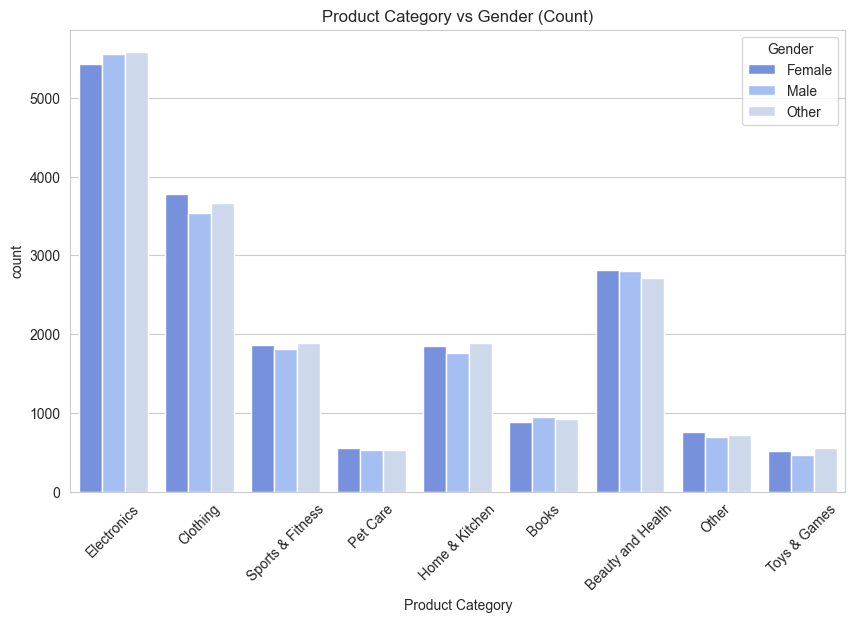

In [66]:
plt.figure(figsize=(10,6))
sns.countplot(x='Product Category', hue='Gender', data=df)

plt.xticks(rotation=45)
plt.title("Product Category vs Gender (Count)")
plt.show()